***Módulos a Importar***

In [208]:
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Punto 1

0. Funciones a Utilizar

In [209]:
# Sabiendo theta1 y theta2, calcula la posicion x y y del punto 1 (Direct Kinematics)

def lista_posiciones(lista_theta1, lista_theta2):

  lista_posx_p1 = []
  lista_posy_p1 = []

  for elemento_unico in range(len(lista_theta1)):
    theta1_unico = lista_theta1[elemento_unico]
    theta2_unico = lista_theta2[elemento_unico]
    lista_posx_p1.append(f_posicionx_p1(theta1_unico, theta2_unico))
    lista_posy_p1.append(f_posiciony_p1(theta1_unico, theta2_unico))

  return lista_posx_p1, lista_posy_p1

In [210]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, graficar su movimiento en el espacio

def graficar_puntos(x1, y1, x2, y2, x3, y3):
    plt.figure(figsize=(8, 8))

    plt.plot(x1, y1, label="Punto 1", color='maroon')
    plt.plot(x2, y2, label="Punto 2", color = 'forestgreen')
    plt.plot(x3, y3, label="Punto 3", color = 'steelblue')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Trayectoria de los 3 puntos")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.show()

In [211]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, graficar su variación de acuerdo al movimiento del actuador lineal s

def graficar_posiciones_actuador(x1, y1, x2, y2, x3, y3, s):

    # Punto 1
    plt.figure(figsize=(10, 6))
    plt.plot(s, x1, label='P1 - x', color='firebrick')
    plt.plot(s, y1, label='P1 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P1 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()

    # Punto 2
    plt.figure(figsize=(10, 6))
    plt.plot(s, x2, label='P2 - x', color='firebrick')
    plt.plot(s, y2, label='P2 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P2 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()

    # Punto 3
    plt.figure(figsize=(10, 6))
    plt.plot(s, x3, label='P3 - x', color='firebrick')
    plt.plot(s, y3, label='P3 - y', color = 'teal')
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Posición [mm]')
    plt.title('Posición del punto P3 vs desplazamiento')
    plt.grid()
    plt.legend()
    plt.show()


In [212]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, calcular sus respectivos ángulos con respecto al Eje Vertical

def angulo_respecto_a_eje(posicionesx, posicionesy):
    angulos = []
    for elemento in range(len(posicionesx)):
        componentex = posicionesx[elemento]
        componentey = posicionesy[elemento]
        angulo_unico = np.arctan(componentex/componentey)
        angulo_unico = np.rad2deg(angulo_unico)
        angulos.append(angulo_unico)
    return angulos

In [213]:
# Sabiendo los ángulos de cada punto con respecto al Eje Vertical, graficar su variación de acuerdo al movimiento del actuador lineal s

def graficar_angulos_actuador(angulos1, angulos2, angulos3, s):

    plt.figure(figsize=(10, 6))
    plt.plot(s, angulos1, label='Angulo P1 - x', color = 'dodgerblue' )
    plt.plot(s, angulos2, label='Angulo P2 - x', color = 'rebeccapurple' )
    plt.plot(s, angulos3, label='Angulo P3 - x', color = 'darkorange' )
    plt.xlabel('Desplazamiento del actuador [mm]')
    plt.ylabel('Ángulo [deg]')
    plt.title('Ángulos de los Puntos respecto al Eje X')
    plt.grid()
    plt.legend()
    plt.show()

1. Definición del Modelo

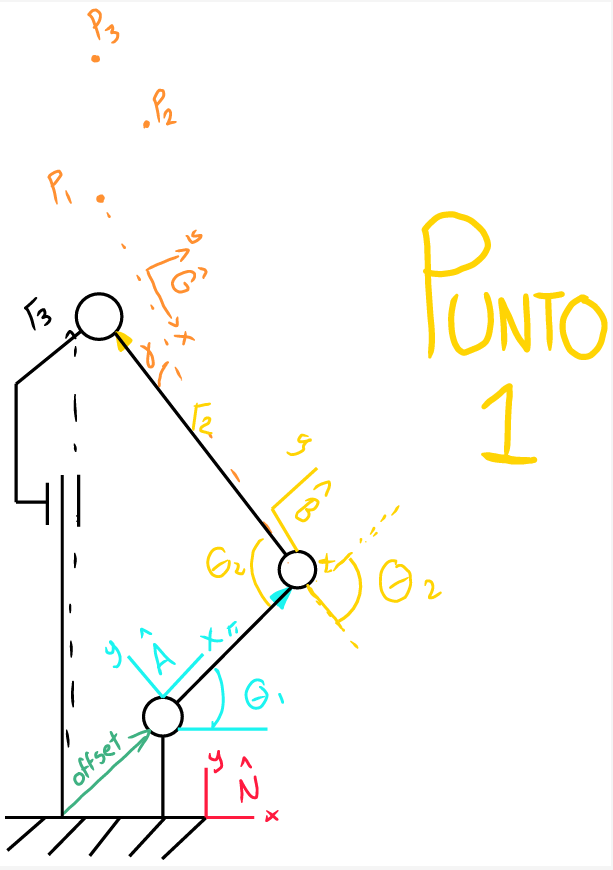

In [214]:
# 1. Definición de Variables
theta, theta2 = dynamicsymbols('theta theta2')
l1, l2, l3_min, s, px, py = sp.symbols('l1 l2 l3_min s px py')

# s == Que tanto se esta expandiendo desde su punto de compresión maximo (entre 0 / completamente comprimido y 20 / completamente estirado)

# 2. Definición de Marcos
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', (theta, N.z))
B = A.orientnew('B', 'Axis', (-theta2, A.z))

# 3. Definición de Medidas y Vectores
l3 = l3_min + s
offset = px*N.x + py*N.y
r1 = l1*A.x
r2 = -l2*B.x
r3 = l3*N.y

# 4. Definición de Ecuaciones y Loop
loop = r1 + r2 - r3 -offset
eq_x = loop.dot(N.x)
eq_y = loop.dot(N.y)
eq = [eq_x, eq_y]

# 5. Conversión a función numérica
fun_eq = sp.lambdify((theta, theta2, l1, l2, l3_min, s, px, py), eq, "numpy")

# 6. Fijación de Valores
val = {
    l1: 30,
    l2: 30,
    l3_min: 30,
    px: 10,
    py: 5,
}
s_val = np.linspace(0, 20, 100)

# 7. Aproach Numérico (hallar theta1 y theta2)

estimacion_angulos = [np.radians(45), np.radians(90)]
theta1_sol = []
theta2_sol = []

for s_num in s_val:
  regleta = lambda v: fun_eq(*v, val[l1],val[l2], val[l3_min],s_num,val[px],val[py])
  solu=fsolve(regleta,estimacion_angulos)
  theta1_sol.append(solu[0])
  theta2_sol.append(solu[1])
  estimacion_angulos=solu


print(theta1_sol)

[np.float64(0.3735726061346202), np.float64(0.3791689667368741), np.float64(0.38476391310247826), np.float64(0.3903578716690549), np.float64(0.39595126868827213), np.float64(0.4015445304606573), np.float64(0.4071380835727231), np.float64(0.4127323551367031), np.float64(0.4183277730332381), np.float64(0.42392476615737396), np.float64(0.4295237646682475), np.float64(0.4351252002428447), np.float64(0.4407295063342363), np.float64(0.4463371184347184), np.float64(0.45194847434429314), np.float64(0.4575640144449563), np.float64(0.4631841819812776), np.float64(0.4688094233477806), np.float64(0.47444018838366236), np.float64(0.4800769306754141), np.float64(0.48572010786794184), np.float64(0.4913701819848157), np.float64(0.49702761975831405), np.float64(0.5026928929699669), np.float64(0.5083664788023475), np.float64(0.5140488602029071), np.float64(0.5197405262606934), np.float64(0.5254419725968541), np.float64(0.5311537017698817), np.float64(0.5368762236966186), np.float64(0.5426100560901124), 

Plus. Gráfica Ángulos

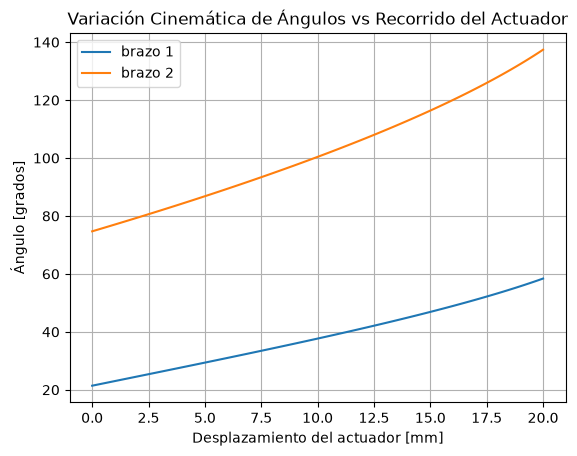

In [215]:
plt.plot(s_val, np.degrees(theta1_sol), label=r'brazo 1')
plt.plot(s_val, np.degrees(theta2_sol), label=r'brazo 2')
plt.xlabel('Desplazamiento del actuador [mm]')
plt.ylabel('Ángulo [grados]')
plt.title('Variación Cinemática de Ángulos vs Recorrido del Actuador')
plt.grid()
plt.legend()
plt.show()

B. Trayectoria en el Espacio de los Puntos

In [216]:
dp1 = sp.symbols('dp1')
gamma1 = sp.symbols('gamma1')
valores_gamma = {gamma1:np.deg2rad(35), dp1:45}

vector_origen_b = offset + r1

G = A.orientnew('G', 'Axis', (-theta2 - gamma1, A.z))

vector_p1 = (vector_origen_b + dp1 *-G.x).express(N).subs(val).subs(valores_gamma)

f_posicionx_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.x),"numpy")
f_posiciony_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.y),"numpy")


posicionesx_p1, posicionesy_p1 = lista_posiciones(theta1_sol,theta2_sol)

vp1_p2 = [5,15]
vp1_p3 = [0,30]

posicionesx_p2 = [xi + vp1_p2[0] for xi in posicionesx_p1]
posicionesy_p2 = [yi + vp1_p2[1] for yi in posicionesy_p1]
posicionesx_p3 = [xi + vp1_p3[0] for xi in posicionesx_p1]
posicionesy_p3 = [yi + vp1_p3[1] for yi in posicionesy_p1]

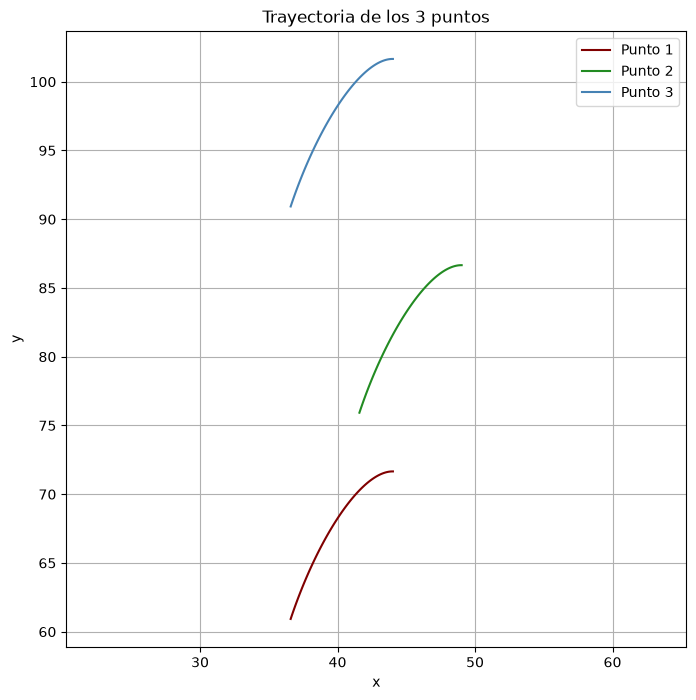

In [217]:
graficar_puntos(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3)

C. Posición en Función del Desplazamiento del Actuador Lineal

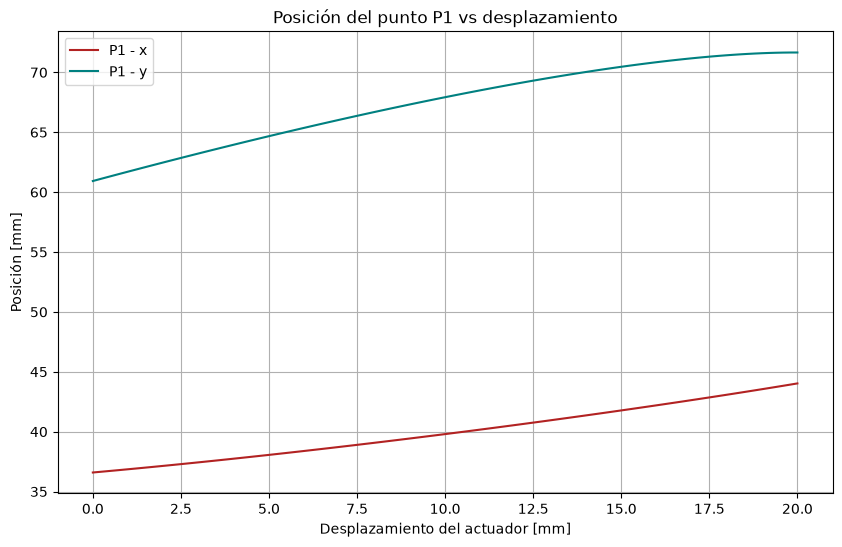

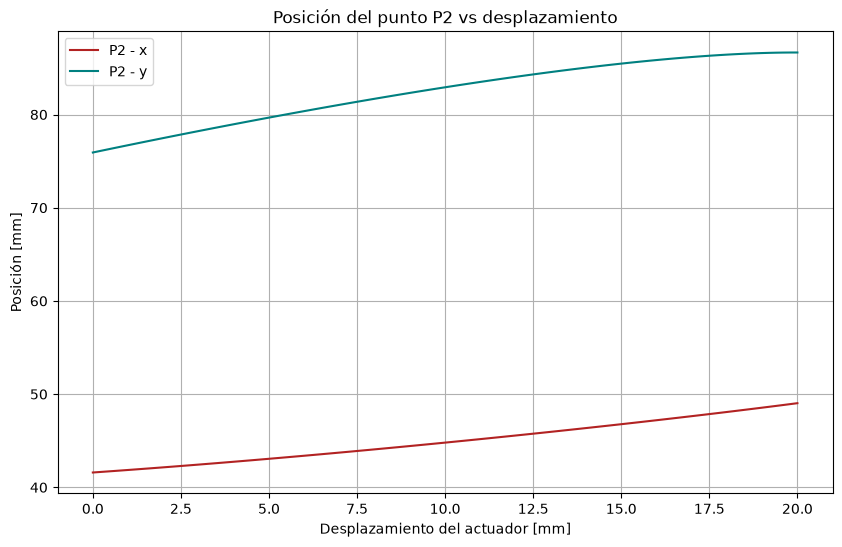

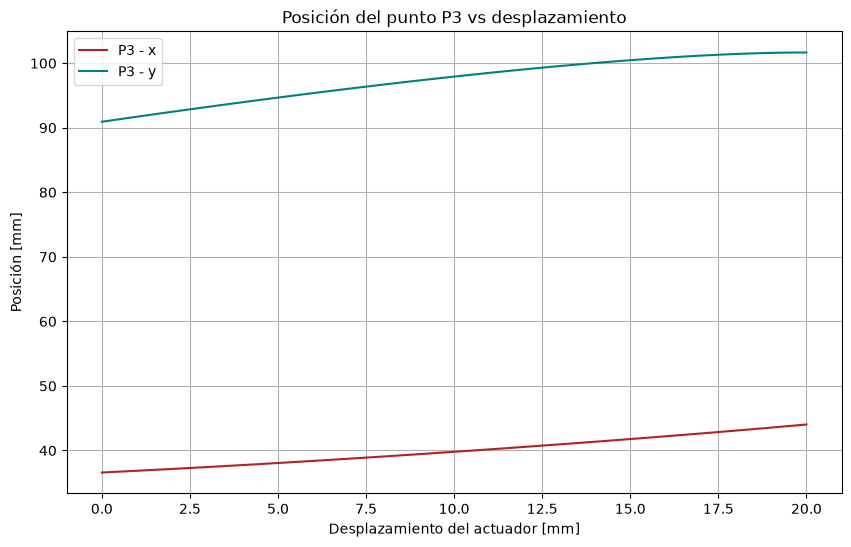

In [218]:
graficar_posiciones_actuador(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3, s_val)

D. Ángulos Respecto al Eje X (En Nuestro Caso Y)

In [219]:
angulos_p1 = angulo_respecto_a_eje(posicionesx_p1, posicionesy_p1)
angulos_p2 = angulo_respecto_a_eje(posicionesx_p2, posicionesy_p2)
angulos_p3 = angulo_respecto_a_eje(posicionesx_p3, posicionesy_p3)

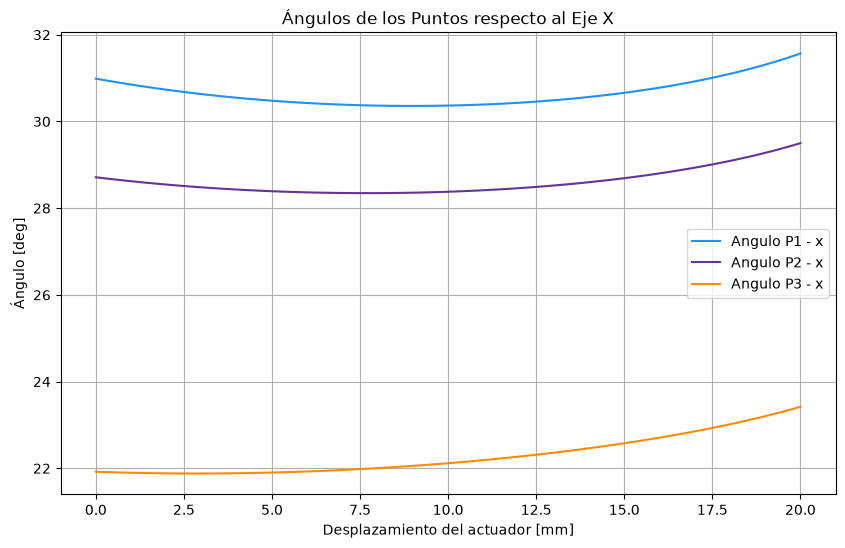

In [220]:
graficar_angulos_actuador(angulos_p1, angulos_p2, angulos_p3, s_val)

# Punto 2

0. Funciones Nuevas a Utilizar

In [ ]:
# Sabiendo theta1 y theta2 Y S, calcula la posicion x y y del punto 1 (Direct Kinematics)

def lista_posiciones_s(lista_theta1, lista_theta2, s_val):

  lista_posx_p1 = []
  lista_posy_p1 = []

  for elemento_unico in range(len(lista_theta1)):
    theta1_unico = lista_theta1[elemento_unico]
    theta2_unico = lista_theta2[elemento_unico]
    s_unico = s_val[elemento_unico]
    lista_posx_p1.append(f_posicionx_p1(theta1_unico, theta2_unico, s_unico))
    lista_posy_p1.append(f_posiciony_p1(theta1_unico, theta2_unico, s_unico))

  return lista_posx_p1, lista_posy_p1

1. Definición del Modelo TOCA CAMBIAR EL ESQUEMÁTICO

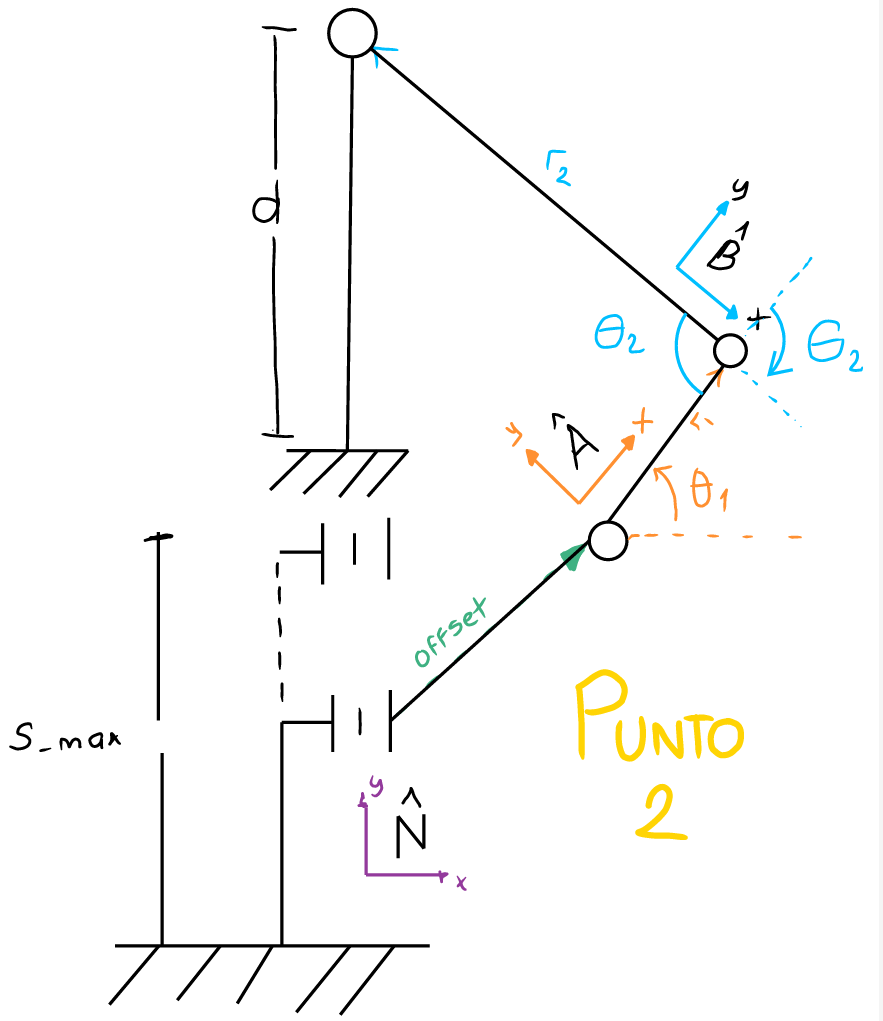

In [236]:
# 1. Definición de Variables
theta, theta2 = dynamicsymbols('theta theta2')
ox, oy, l1,l2, d_fija, s = sp.symbols('ox oy l1 l2 d_fija s')

# 2. Definición de Marcos
N = ReferenceFrame('N')
A= N.orientnew('A', 'Axis', (theta, N.z))
B= A.orientnew('B', 'Axis', (-theta2, N.z))

# 3. Definición de Medidas y Vectores
l3= d_fija
offset= ox*N.x +oy*N.y
subida_piston = s*N.y
r1= l1*A.x
r2= -l2*B.x
r3= l3*N.y 

# 4. Definición de Ecuaciones y Loop
loop= subida_piston + r1+r2-r3 + offset
eqx= loop.dot(N.x)
eqy= loop.dot(N.y)
eq=[eqx, eqy]

# 5. Conversión a Función Numérica
fun_eq=sp.lambdify((theta, theta2,ox,oy,l1,l2,d_fija,s),eq,"numpy")

# 6. Fijación de Valores
val={ox:7, oy:2 ,l1:40, l2:50,d_fija:60}
s_val=np.linspace(0,20,100)

# 7. Approach Numérico (hallar theta1 y theta2)
angulos_estimados=[np.radians(50),np.radians(70)]
theta1_sol=[]
theta2_sol=[]
for s_num  in s_val:
  regleta=lambda v: fun_eq( *v,val[ox],val[oy],val[l1],val[l2],val[d_fija],s_num)
  solu=fsolve(regleta, angulos_estimados)
  theta1_sol.append(solu[0])
  theta2_sol.append(solu[1])
  angulos_estimados= solu


Plus. Gráfica Ángulos

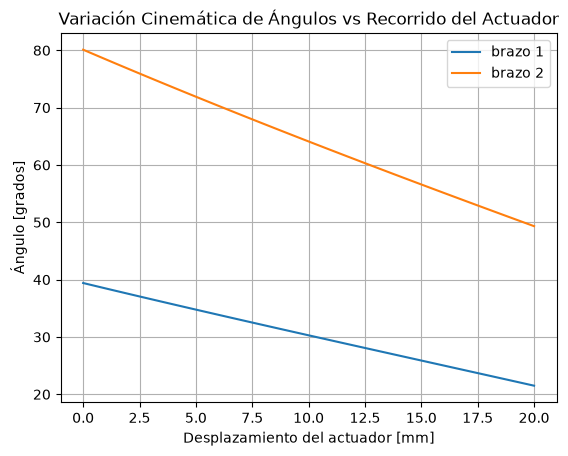

In [222]:
plt.plot(s_val, np.degrees(theta1_sol), label=r'brazo 1')
plt.plot(s_val, np.degrees(theta2_sol), label=r'brazo 2')
plt.xlabel('Desplazamiento del actuador [mm]')
plt.ylabel('Ángulo [grados]')
plt.title('Variación Cinemática de Ángulos vs Recorrido del Actuador')
plt.grid()
plt.legend()
plt.show()

B. Trayectoria en el Espacio de los Puntos

(-60*sin(theta2(t) + 0.436332312998582)*sin(theta(t)) - 60*cos(theta2(t) + 0.436332312998582)*cos(theta(t)) + 40*cos(theta(t)) + 7)*N.x + (s + 60*sin(theta2(t) + 0.436332312998582)*cos(theta(t)) - 60*sin(theta(t))*cos(theta2(t) + 0.436332312998582) + 40*sin(theta(t)) + 2)*N.y

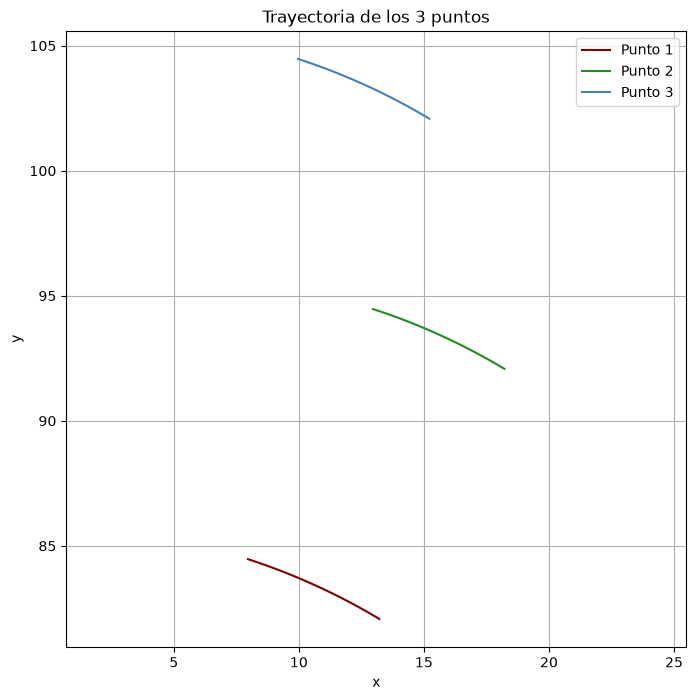

In [240]:
dp1 = sp.symbols('dp1')
gamma = sp.symbols('gamma')
valores_gamma = {gamma:np.deg2rad(25), dp1:60}

vector_origen_b = subida_piston + offset + r1

G = A.orientnew('G', 'Axis', (-theta2 - gamma, A.z))

vector_p1 = (vector_origen_b + dp1 *-G.x).express(N).subs(val).subs(valores_gamma)
display(vector_p1)

f_posicionx_p1 = sp.lambdify((theta,theta2,s),vector_p1.dot(N.x),"numpy")
f_posiciony_p1 = sp.lambdify((theta,theta2,s),vector_p1.dot(N.y),"numpy")


posicionesx_p1, posicionesy_p1 = lista_posiciones_s(theta1_sol,theta2_sol, s_val)


vp1_p2 = [5,10]
vp1_p3 = [2,20]

posicionesx_p2 = [xi + vp1_p2[0] for xi in posicionesx_p1]
posicionesy_p2 = [yi + vp1_p2[1] for yi in posicionesy_p1]
posicionesx_p3 = [xi + vp1_p3[0] for xi in posicionesx_p1]
posicionesy_p3 = [yi + vp1_p3[1] for yi in posicionesy_p1]



graficar_puntos(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3)

C. Posición en Función del Desplazamiento del Actuador Lineal

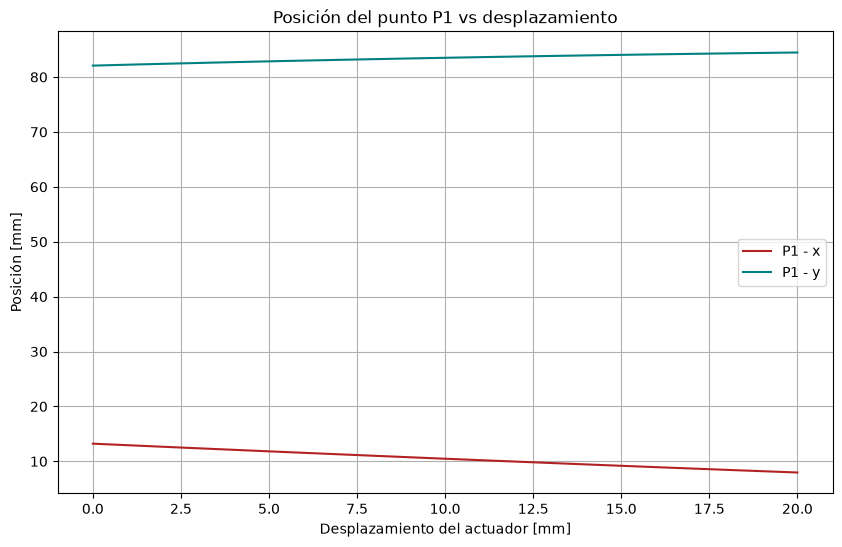

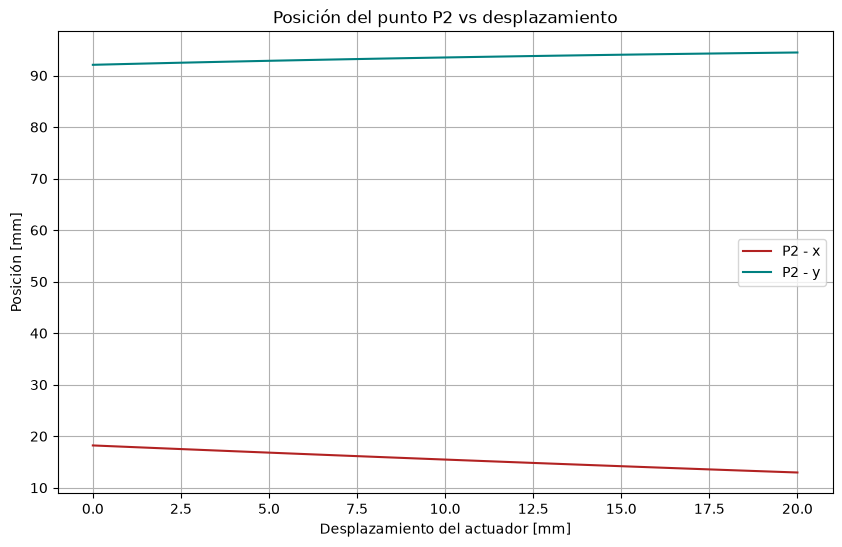

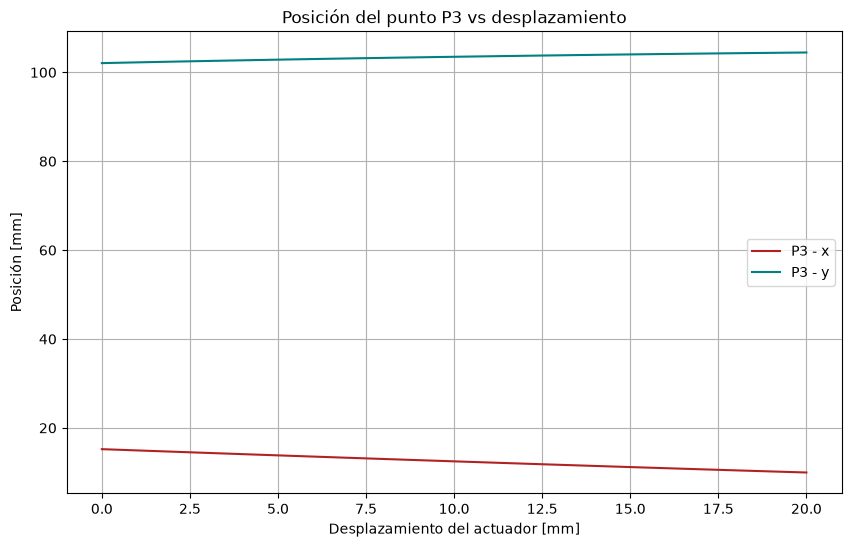

In [241]:
graficar_posiciones_actuador(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3, s_val)

D. Ángulos Respecto al Eje X (En Nuestro Caso Y)

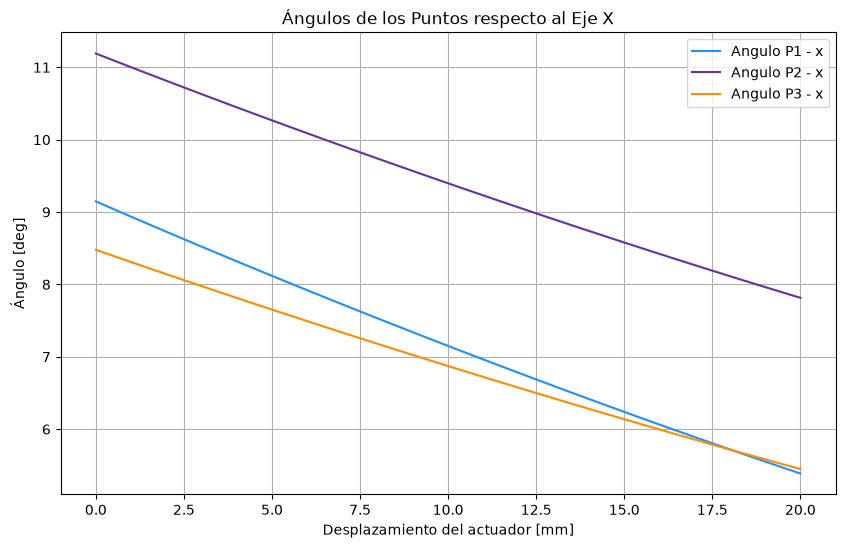

In [242]:
angulos_p1 = angulo_respecto_a_eje(posicionesx_p1, posicionesy_p1)
angulos_p2 = angulo_respecto_a_eje(posicionesx_p2, posicionesy_p2)
angulos_p3 = angulo_respecto_a_eje(posicionesx_p3, posicionesy_p3)
graficar_angulos_actuador(angulos_p1, angulos_p2, angulos_p3, s_val)